In [641]:
###################################################################  
#
# Code written by Lecia Cheok Yun Zhen (A0259532Y)
# Date: November 4, 2025
#
# 
# Methods analyzed/used: 
#      0. Feature Selection using Variance Threshold
#      1a. Random Forests (180 selected features)
#      1b. Random Forests with tuned parameters using RandomizedSearch CV (180 selected features)
#      2a. AdaBoost (180 selected features)
#      2b. AdaBoost with tuned parameters using RandomizedSearch CV (180 selected features)
#      3a. XGBoost (180 selected features)
#      3b. XGBoost with tuned parameters using RandomizedSearch CV (180 selected features)
#      4a. Light GBM (180 selected features)
#      4b. Light GBM with tuned parameters using RandomizedSearch CV (180 selected features)
#      5a. KNN Regression (180 selected features)
#      5b. KNN Regression with tuned parameters using RandomizedSearch CV (180 selected features)
#      6a. Neural Network (180 selected features)
#      6b. Neural Network with tuned parameters using RandomizedSearch CV (180 selected features)
#      7a. Equally Weighted Ensemble
#      7b. Optimally Weighted Ensemble

# Final predictive model is 
#      Optimally Weighted Ensemble with 180 features selected by the Variance Threshold Method
#
###################################################################

In [642]:
import pandas as pd
import numpy as np
from scipy.stats import randint, uniform
import sklearn.linear_model as lm 
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import lightgbm as lgb

## Data Pre-Processing

In [643]:
# Same data cleaning steps as before
#df_labeled = pd.read_csv('./hw3_labeled.csv', index_col="ID")
#df_holdout = pd.read_csv('./hw3_unlabeled.csv', index_col="ID")
df_labeled = pd.read_csv('hw3_labeled.csv', index_col="ID")
df_holdout = pd.read_csv('hw3_unlabeled.csv', index_col="ID")
# combine together
df_all = pd.concat([df_labeled, df_holdout])

In [644]:
# simple preprocessing: e.g., convert strings to dummies. 
cols_with_str = df_all.select_dtypes(exclude=[np.number]).columns
df_all = pd.get_dummies(df_all, columns = cols_with_str,drop_first=True)

# simple preprocessing: e.g., standard scaling. 
X = df_all.drop(columns="SalePrice")
y = df_all["SalePrice"]

ss = StandardScaler()
X_scaled = ss.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns = X.columns, index = df_all.index) 

# merge again
df_all = pd.concat([y, X_scaled], axis = 1)

In [645]:
# re-split data
df_holdout = df_all.tail(df_holdout.shape[0]).copy()
df_labeled = df_all.head(df_labeled.shape[0]).copy()

In [646]:
# get target/predictors 
X = df_labeled.drop(columns="SalePrice")
y = df_labeled["SalePrice"]

# split into train and test 
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.30, random_state = 0)

In [647]:
# get predictors from holdout sample
X_holdout = df_holdout.drop(columns="SalePrice")

In [648]:
X_train.shape

(490, 187)

### Feature Selection
Due to the high dimensionality, feature selection will be included as part of the modeling process.

C:\Users\lecia\AppData\Local\Temp\ipykernel_25788\160538656.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


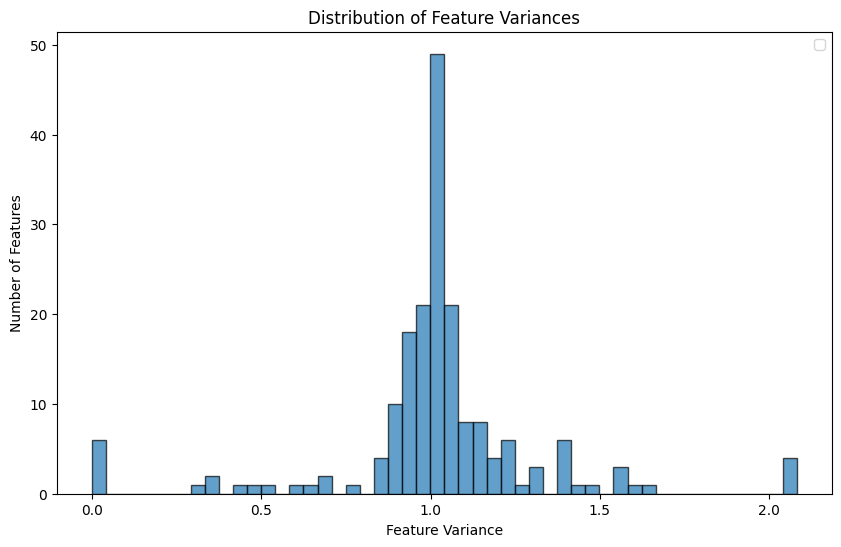

In [649]:
# Calculate variance statistics of the features
variances = X.var()
# Show distribution of variances
plt.figure(figsize=(10, 6))
plt.hist(variances, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Feature Variance')
plt.ylabel('Number of Features')
plt.title('Distribution of Feature Variances')
plt.legend()
plt.show()

In [650]:
# Variance Threshold Features
# Clear separation around variance 0.7 - 1.0
# Apply Variance Threshold of 0.7 to remove features with variance below 70% of the maximum variance.
selector_VT = VarianceThreshold(threshold=0.7)
X_reduced_VT = selector_VT.fit_transform(X)

# Get selected feature names
selected_features_VT = X.columns[selector_VT.get_support()].tolist()
print(f"Variance Threshold: {len(selected_features_VT)} features")

# Get subset of features selected for train, test and holdout
X_train = X_train[selected_features_VT]
X_test = X_test[selected_features_VT]
X_holdout = X_holdout[selected_features_VT]

Variance Threshold: 172 features


# Evaluate learning methods
We will evaluate the following metrics (in order of priority):
- MSE: Measures the average squared difference between the predicted and actual housing prices. Large errors are penalized more heavily because of squaring, which is useful for identifying models that avoid very poor predictions.
- RMSE: The square root of MSE, expressed in the same units as housing prices (e.g., dollars). RMSE is more interpretable than MSE and highlights the typical magnitude of prediction errors.
- R^2: Represents the proportion of variance in housing prices explained by the model. Values range from 0 to 1 (or negative if the model is worse than predicting the mean), with higher values indicating that the model captures more of the variability in housing prices.

## Ensemble Methods

### Bagging-Based Ensemble Methods

#### Random Forest 

In [651]:
# Define AdaBoost model
rf_model = RandomForestRegressor(
    n_estimators=100,      # number of trees in the forest
    max_depth=None,
    random_state=0,
    n_jobs=-1
    )

# Fit
rf_model.fit(X_train, y_train)

# Evaluate
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Train metrics
rf_train_mse = mean_squared_error(y_train, y_train_pred)
rf_train_rmse = np.sqrt(rf_train_mse)
rf_train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
rf_test_mse = mean_squared_error(y_test, y_test_pred)
rf_test_rmse = np.sqrt(rf_test_mse)
rf_test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Train MSE: {rf_train_mse:.4f}, RMSE: {rf_train_rmse:.4f}, R²: {rf_train_r2:.4f}")
print(f"Test  MSE: {rf_test_mse:.4f}, RMSE: {rf_test_rmse:.4f}, R²: {rf_test_r2:.4f}")

Train MSE: 125650278.9408, RMSE: 11209.3835, R²: 0.9805
Test  MSE: 805270286.3521, RMSE: 28377.2847, R²: 0.8499


##### Hyperparameter Tuning: Randomized Search CV

In [652]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import numpy as np

# Define parameter distributions
param_dist = {
    'n_estimators': randint(100, 300), # n_estimators: More trees = better performance but slower training
    'max_depth': randint(3, 20), # max_depth: Controls how deep each tree can grow
    'min_samples_split': randint(2, 10), # min_samples_split: Prevents splitting nodes with too few samples
    'min_samples_leaf': randint(2, 10), # min_samples_leaf: Ensures leaf nodes have minimum samples
    'max_features': ['sqrt', 'log2', None] # controls randomness in feature selection per split
}

# Define model
rf = RandomForestRegressor(random_state=0, n_jobs=-1)

# Randomized search setup
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,                         # try 20 random combinations
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=0,
    verbose=2,
    n_jobs=-1
)

# Fit
rf_random.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", rf_random.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 158}


In [653]:
best_rf = rf_random.best_estimator_  # Random forest trained with best params
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# Train metrics
rf_train_mse = mean_squared_error(y_train, y_train_pred)
rf_train_rmse = np.sqrt(rf_train_mse)
rf_train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
rf_test_mse = mean_squared_error(y_test, y_test_pred)
rf_test_rmse = np.sqrt(rf_test_mse)
rf_test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Train MSE: {rf_train_mse:.4f}, RMSE: {rf_train_rmse:.4f}, R²: {rf_train_r2:.4f}")
print(f"Test  MSE: {rf_test_mse:.4f}, RMSE: {rf_test_rmse:.4f}, R²: {rf_test_r2:.4f}")

Train MSE: 374181008.5575, RMSE: 19343.7589, R²: 0.9420
Test  MSE: 827028039.3491, RMSE: 28758.0952, R²: 0.8458


### Boosting-Based Ensemble Method

#### AdaBoost

In [654]:
# Define AdaBoost model
ada_model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=1),
    n_estimators=100,
    learning_rate=0.1,
    random_state=0
)

# Fit
ada_model.fit(X_train, y_train)

# Evaluate
y_train_pred = ada_model.predict(X_train)
y_test_pred = ada_model.predict(X_test)

# Train metrics
adaboost_train_mse = mean_squared_error(y_train, y_train_pred)
adaboost_train_rmse = np.sqrt(adaboost_train_mse)
adaboost_train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
adaboost_test_mse = mean_squared_error(y_test, y_test_pred)
adaboost_test_rmse = np.sqrt(adaboost_test_mse)
adaboost_test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Train MSE: {adaboost_train_mse:.4f}, RMSE: {adaboost_train_rmse:.4f}, R²: {adaboost_train_r2:.4f}")
print(f"Test  MSE: {adaboost_test_mse:.4f}, RMSE: {adaboost_test_rmse:.4f}, R²: {adaboost_test_r2:.4f}")

Train MSE: 2893079324.9648, RMSE: 53787.3528, R²: 0.5516
Test  MSE: 3205109930.3074, RMSE: 56613.6903, R²: 0.4025


##### Hyperparameter Tuning: Randomized Search CV

In [655]:
ada = AdaBoostRegressor(random_state=0)

ada_param_dist = {
    'n_estimators': randint(50, 300), # Number of boosting stages to run: try 50-299
    'learning_rate': uniform(0.01, 1.0), # Shrinks contribution of each tree: try 0.01-1.0
    'estimator': [DecisionTreeRegressor(max_depth=d) for d in range(1, 10)]  # Boost base estimator (weak learner)
}

ada_random = RandomizedSearchCV(
    estimator=ada,
    param_distributions=ada_param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=0,
    verbose=2,
    n_jobs=-1
)

ada_random.fit(X_train, y_train)
print("Best AdaBoost Parameters:", ada_random.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best AdaBoost Parameters: {'estimator': DecisionTreeRegressor(max_depth=9), 'learning_rate': np.float64(0.9123485831739843), 'n_estimators': 281}


In [656]:
best_ada = ada_random.best_estimator_  # Random forest trained with best params
y_train_pred = best_ada.predict(X_train)
y_test_pred = best_ada.predict(X_test)

# Train metrics
ada_train_mse = mean_squared_error(y_train, y_train_pred)
ada_train_rmse = np.sqrt(ada_train_mse)
ada_train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
ada_test_mse = mean_squared_error(y_test, y_test_pred)
ada_test_rmse = np.sqrt(ada_test_mse)
ada_test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Train MSE: {ada_train_mse:.4f}, RMSE: {ada_train_rmse:.4f}, R²: {ada_train_r2:.4f}")
print(f"Test  MSE: {ada_test_mse:.4f}, RMSE: {ada_test_rmse:.4f}, R²: {ada_test_r2:.4f}")

Train MSE: 9679809.1113, RMSE: 3111.2392, R²: 0.9985
Test  MSE: 793306928.6430, RMSE: 28165.7048, R²: 0.8521


#### XGBoost

In [657]:
# Define model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=0,
    objective='reg:squarederror'
)

# Fit
xgb_model.fit(X_train, y_train)

# Evaluate
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# Train metrics
xgb_train_mse = mean_squared_error(y_train, y_train_pred)
xgb_train_rmse = np.sqrt(xgb_train_mse)
xgb_train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
xgb_test_mse = mean_squared_error(y_test, y_test_pred)
xgb_test_rmse = np.sqrt(xgb_test_mse)
xgb_test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Train MSE: {xgb_train_mse:.4f}, RMSE: {xgb_train_rmse:.4f}, R²: {xgb_train_r2:.4f}")
print(f"Test  MSE: {xgb_test_mse:.4f}, RMSE: {xgb_test_rmse:.4f}, R²: {xgb_test_r2:.4f}")

Train MSE: 17250175.0346, RMSE: 4153.3330, R²: 0.9973
Test  MSE: 876743603.1058, RMSE: 29609.8565, R²: 0.8365


##### Hyperparameter Tuning: Randomized Search CV

In [658]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=0)

xgb_param_dist = {
    'n_estimators': randint(50, 500), # try 50 - 100 boosting iterations
    'max_depth': randint(3, 15), # Tree complexity control
    'learning_rate': uniform(0.01, 0.3), # Step size shrinkage
    'subsample': uniform(0.5, 0.5), # Row sampling for each tree
    'colsample_bytree': uniform(0.5, 0.5) # Column sampling for each tree
}

xgb_random = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=0,
    verbose=2,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)
print("Best XGBoost Parameters:", xgb_random.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGBoost Parameters: {'colsample_bytree': np.float64(0.5854547925680226), 'learning_rate': np.float64(0.1174456500908575), 'max_depth': 3, 'n_estimators': 448, 'subsample': np.float64(0.8039153343577339)}


In [659]:
best_xgb = xgb_random.best_estimator_  # Random forest trained with best params
y_train_pred = best_xgb.predict(X_train)
y_test_pred = best_xgb.predict(X_test)

# Train metrics
xgb_train_mse = mean_squared_error(y_train, y_train_pred)
xgb_train_rmse = np.sqrt(xgb_train_mse)
xgb_train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
xgb_test_mse = mean_squared_error(y_test, y_test_pred)
xgb_test_rmse = np.sqrt(xgb_test_mse)
xgb_test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Train MSE: {xgb_train_mse:.4f}, RMSE: {xgb_train_rmse:.4f}, R²: {xgb_train_r2:.4f}")
print(f"Test  MSE: {xgb_test_mse:.4f}, RMSE: {xgb_test_rmse:.4f}, R²: {xgb_test_r2:.4f}")

Train MSE: 4770663.2180, RMSE: 2184.1848, R²: 0.9993
Test  MSE: 572096813.5054, RMSE: 23918.5454, R²: 0.8933


#### LightGBM

In [660]:
# Define model
lgb_model = lgb.LGBMRegressor(
    n_estimators=50,
    max_depth=10,
    learning_rate=0.1,
    random_state=0
)

# Fit
lgb_model.fit(X_train, y_train)

# Evaluate
y_train_pred = lgb_model.predict(X_train)
y_test_pred = lgb_model.predict(X_test)

# Train metrics
lgb_train_mse = mean_squared_error(y_train, y_train_pred)
lgb_train_rmse = np.sqrt(lgb_train_mse)
lgb_train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
lgb_test_mse = mean_squared_error(y_test, y_test_pred)
lgb_test_rmse = np.sqrt(xgb_test_mse)
lgb_test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Train MSE: {lgb_train_mse:.4f}, RMSE: {lgb_train_rmse:.4f}, R²: {lgb_train_r2:.4f}")
print(f"Test  MSE: {lgb_test_mse:.4f}, RMSE: {lgb_test_rmse:.4f}, R²: {lgb_test_r2:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001229 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1955
[LightGBM] [Info] Number of data points in the train set: 490, number of used features: 105
[LightGBM] [Info] Start training from score 182775.316327
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [661]:
lgb_model = lgb.LGBMRegressor(random_state=0)

lgb_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(3, 20),
    'learning_rate': uniform(0.01, 0.3),
    'num_leaves': randint(20, 100),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5)
}

lgb_random = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=lgb_param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=0,
    verbose=2,
    n_jobs=-1
)

lgb_random.fit(X_train, y_train)
print("Best LightGBM Parameters:", lgb_random.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004710 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1955
[LightGBM] [Info] Number of data points in the train set: 490, number of used features: 105
[LightGBM] [Info] Start training from score 182775.316327
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [662]:
best_lgb = lgb_random.best_estimator_  # Random forest trained with best params
y_train_pred = best_lgb.predict(X_train)
y_test_pred = best_lgb.predict(X_test)

# Train metrics
lgb_train_mse = mean_squared_error(y_train, y_train_pred)
lgb_train_rmse = np.sqrt(lgb_train_mse)
lgb_train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
lgb_test_mse = mean_squared_error(y_test, y_test_pred)
lgb_test_rmse = np.sqrt(lgb_test_mse)
lgb_test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Train MSE: {lgb_train_mse:.4f}, RMSE: {lgb_train_rmse:.4f}, R²: {lgb_train_r2:.4f}")
print(f"Test  MSE: {lgb_test_mse:.4f}, RMSE: {lgb_test_rmse:.4f}, R²: {lgb_test_r2:.4f}")

Train MSE: 33830576.0465, RMSE: 5816.4058, R²: 0.9948
Test  MSE: 611948167.8663, RMSE: 24737.5861, R²: 0.8859


## KNN Regression

In [663]:
knn_model = KNeighborsRegressor(n_neighbors=5)
# Fit
knn_model.fit(X_train, y_train)

# Evaluate
y_train_pred = knn_model.predict(X_train)
y_test_pred = knn_model.predict(X_test)

# Train metrics
knn_train_mse = mean_squared_error(y_train, y_train_pred)
knn_train_rmse = np.sqrt(knn_train_mse)
knn_train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
knn_test_mse = mean_squared_error(y_test, y_test_pred)
knn_test_rmse = np.sqrt(knn_test_mse)
knn_test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Train MSE: {knn_train_mse:.4f}, RMSE: {knn_train_rmse:.4f}, R²: {knn_train_r2:.4f}")
print(f"Test  MSE: {knn_test_mse:.4f}, RMSE: {knn_test_rmse:.4f}, R²: {knn_test_r2:.4f}")

Train MSE: 1106267716.6708, RMSE: 33260.6031, R²: 0.8285
Test  MSE: 1336020519.6579, RMSE: 36551.6145, R²: 0.7509


### Randomized Search CV

In [664]:
# Define parameter distributions
param_dist = {
    'n_neighbors': randint(1, 20),      # number of neighbors to try
    'weights': ['uniform', 'distance'], # weight function
    'p': [1, 2, 3]                         # distance metric: 1=Manhattan, 2=Euclidean
}

# Define model
knn = KNeighborsRegressor()

# Randomized search
knn_random = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_dist,
    n_iter=20,                 # number of random combinations to try
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=0,
    verbose=2,
    n_jobs=-1
)
# Fit
knn_random.fit(X_train, y_train)

print("Best Parameters:", knn_random.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'n_neighbors': 4, 'p': 1, 'weights': 'distance'}


In [665]:
# Fit KNN model with tuned hyperparameters
best_knn = knn_random.best_estimator_

# Evaluate
y_train_pred = best_knn.predict(X_train)
y_test_pred = best_knn.predict(X_test)

# Train metrics
knn_train_mse = mean_squared_error(y_train, y_train_pred)
knn_train_rmse = np.sqrt(knn_train_mse)
knn_train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
knn_test_mse = mean_squared_error(y_test, y_test_pred)
knn_test_rmse = np.sqrt(knn_test_mse)
knn_test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Train MSE: {knn_train_mse:.4f}, RMSE: {knn_train_rmse:.4f}, R²: {knn_train_r2:.4f}")
print(f"Test  MSE: {knn_test_mse:.4f}, RMSE: {knn_test_rmse:.4f}, R²: {knn_test_r2:.4f}")

Train MSE: 0.0000, RMSE: 0.0000, R²: 1.0000
Test  MSE: 1109634204.5772, RMSE: 33311.1724, R²: 0.7931


## Neural Network

In [666]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(50, 25, 10),
    activation='relu', 
    solver='lbfgs', 
    max_iter=1000, 
    random_state=0
)

# Fit
mlp_model.fit(X_train, y_train)

# Evaluate
y_train_pred = mlp_model.predict(X_train)
y_test_pred = mlp_model.predict(X_test)

# Train metrics
mlp_train_mse = mean_squared_error(y_train, y_train_pred)
mlp_train_rmse = np.sqrt(knn_train_mse)
mlp_train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
mlp_test_mse = mean_squared_error(y_test, y_test_pred)
mlp_test_rmse = np.sqrt(mlp_test_mse)
mlp_test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Train MSE: {mlp_train_mse:.4f}, RMSE: {mlp_train_rmse:.4f}, R²: {mlp_train_r2:.4f}")
print(f"Test  MSE: {mlp_test_mse:.4f}, RMSE: {mlp_test_rmse:.4f}, R²: {mlp_test_r2:.4f}")

Train MSE: 0.0000, RMSE: 0.0000, R²: 1.0000
Test  MSE: 1149988717.0237, RMSE: 33911.4836, R²: 0.7856


### Randomized Search CV

In [667]:
mlp = MLPRegressor(random_state=0, max_iter=2000)

# Define hyperparameter distributions
param_dist = {
    'hidden_layer_sizes': [(50,), (50,25), (100,50), (50,50,25)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'lbfgs', 'sgd'],
    'alpha': uniform(0.0001, 0.01),   # L2 penalty
    'learning_rate_init': uniform(0.001, 0.01)
}

# Randomized search
nn_random = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist,
    n_iter=20,       # number of random combinations
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=0,
    verbose=2,
    n_jobs=-1
)

# Fit
nn_random.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", nn_random.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'activation': 'relu', 'alpha': np.float64(0.009819450024996658), 'hidden_layer_sizes': (50, 50, 25), 'learning_rate_init': np.float64(0.005686512016477016), 'solver': 'lbfgs'}


In [668]:
# Fit the NN with the best parameters
best_nn = nn_random.best_estimator_

# Evaluate
y_train_pred = best_nn.predict(X_train)
y_test_pred = best_nn.predict(X_test)

# Train metrics
nn_train_mse = mean_squared_error(y_train, y_train_pred)
nn_train_rmse = np.sqrt(nn_train_mse)
nn_train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
nn_test_mse = mean_squared_error(y_test, y_test_pred)
nn_test_rmse = np.sqrt(nn_test_mse)
nn_test_r2 = r2_score(y_test, y_test_pred)

print(f"Train MSE: {nn_train_mse:.4f}, RMSE: {nn_train_rmse:.4f}, R²: {nn_train_r2:.4f}")
print(f"Test  MSE: {nn_test_mse:.4f}, RMSE: {nn_test_rmse:.4f}, R²: {nn_test_r2:.4f}")

Train MSE: 0.0000, RMSE: 0.0003, R²: 1.0000
Test  MSE: 908372612.8791, RMSE: 30139.2205, R²: 0.8306


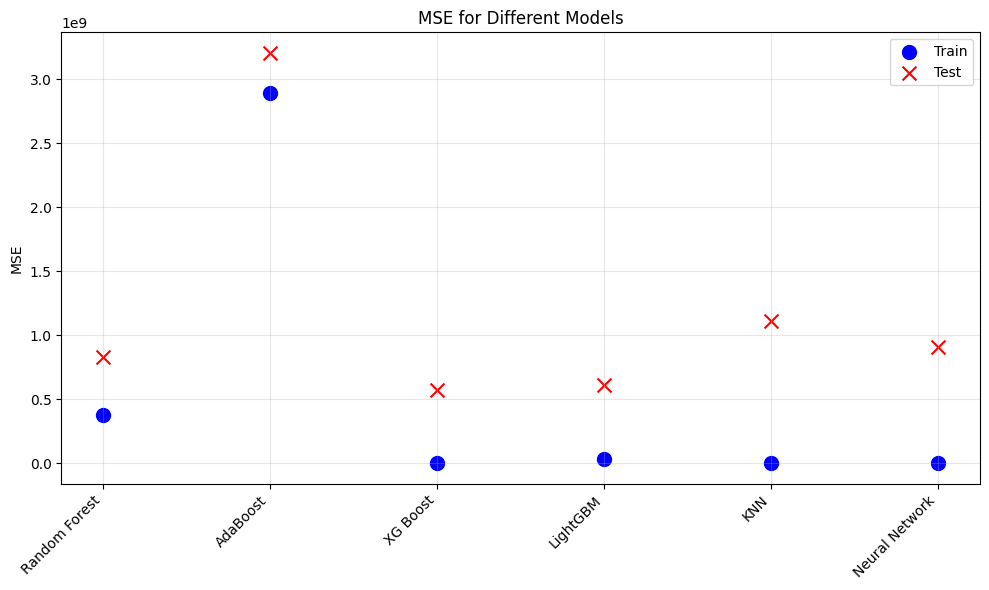

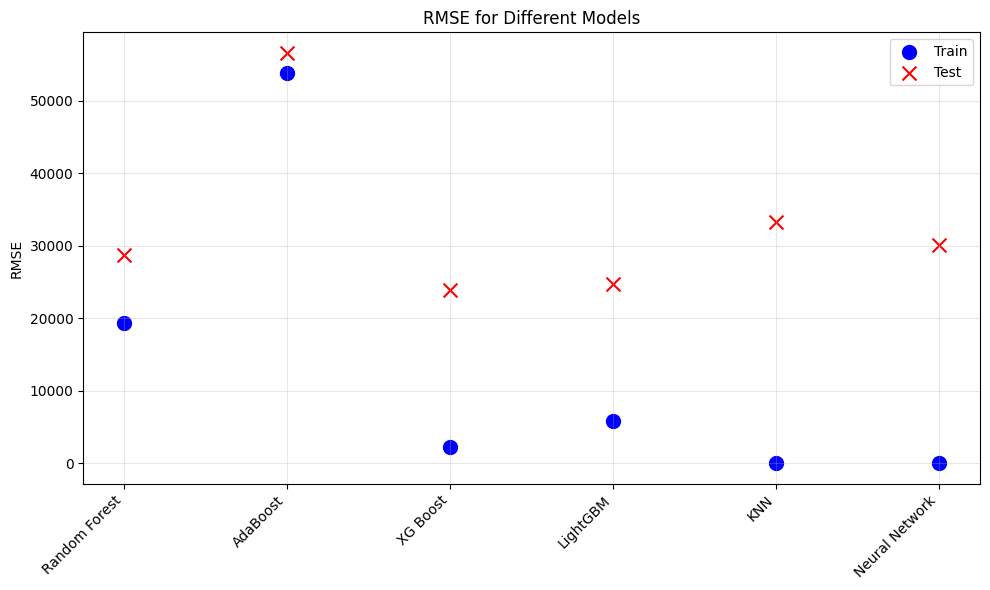

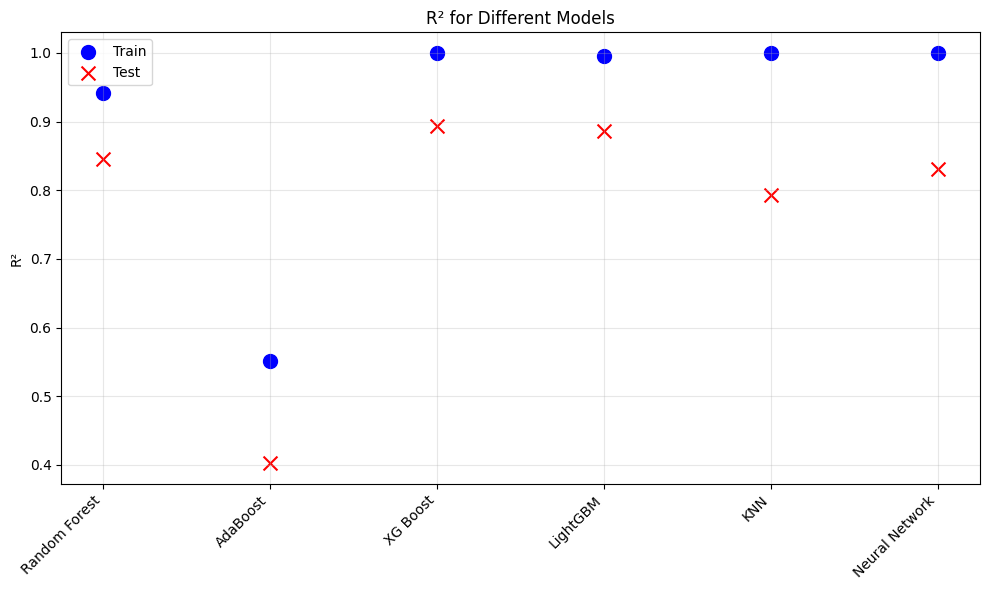

In [669]:
# List all models and metrics
models = ["Random Forest", "AdaBoost", "XG Boost", "LightGBM", "KNN", "Neural Network"]

# Metrics (example, replace with your actual variables)
train_mse_list = [rf_train_mse, adaboost_train_mse, xgb_train_mse, lgb_train_mse, knn_train_mse, nn_train_mse]
test_mse_list  = [rf_test_mse, adaboost_test_mse, xgb_test_mse, lgb_test_mse, knn_test_mse, nn_test_mse]

train_rmse_list = [rf_train_rmse, adaboost_train_rmse, xgb_train_rmse, lgb_train_rmse, knn_train_rmse, nn_train_rmse]
test_rmse_list  = [rf_test_rmse, adaboost_test_rmse, xgb_test_rmse, lgb_test_rmse, knn_test_rmse, nn_test_rmse]

train_r2_list = [rf_train_r2, adaboost_train_r2, xgb_train_r2, lgb_train_r2, knn_train_r2, nn_train_r2]
test_r2_list  = [rf_test_r2, adaboost_test_r2, xgb_test_r2, lgb_test_r2, knn_test_r2, nn_test_r2]

# Define function to create dot plots
def plot_dot(metrics_train, metrics_test, metric_name):
    plt.figure(figsize=(10,6))
    x = np.arange(len(models))
    
    plt.scatter(x, metrics_train, color='blue', marker='o', s=100, label='Train')   # Circle for train
    plt.scatter(x, metrics_test, color='red', marker='x', s=100, label='Test')      # X for test
    
    plt.xticks(x, models, rotation=45, ha='right')
    plt.ylabel(metric_name)
    plt.title(f'{metric_name} for Different Models')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot metrics
plot_dot(train_mse_list, test_mse_list, 'MSE')
plot_dot(train_rmse_list, test_rmse_list, 'RMSE')
plot_dot(train_r2_list, test_r2_list, 'R²')


Evaluating the test MSE, LightGBM, XGBoost, and Random Forest consistently achieve the lowest and fairly similar errors. Neural Network and KNN follow closely, showing moderate performance, while AdaBoost exhibits the highest MSE among all models. These trends are mirrored in the R² comparison, confirming the relative predictive strengths of the models. </br>
Based on these results, we will proceed with stacking models that demonstrate moderate to strong performance, leveraging complementary strengths to potentially improve overall prediction accuracy.</p>
Models selected:
- Random Forest
- XGBoost
- LightGBM
- Neural Network

## Weighted Ensemble Models

In [670]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train predictions
y_train_pred_avg = (best_rf.predict(X_train) +
                    best_xgb.predict(X_train) +
                    best_nn.predict(X_train) +
                    best_lgb.predict(X_train)) / 4

# Test predictions
y_test_pred_avg = (best_rf.predict(X_test) +
                   best_xgb.predict(X_test) +
                   best_nn.predict(X_test) +
                   best_lgb.predict(X_test)) / 4

# Train metrics
avg_train_mse = mean_squared_error(y_train, y_train_pred_avg)
avg_train_rmse = np.sqrt(avg_train_mse)
avg_train_r2 = r2_score(y_train, y_train_pred_avg)

# Test metrics
avg_test_mse = mean_squared_error(y_test, y_test_pred_avg)
avg_test_rmse = np.sqrt(avg_test_mse)
avg_test_r2 = r2_score(y_test, y_test_pred_avg)

# Print results
print("Simple Average Ensemble Metrics")
print(f"Train MSE: {avg_train_mse:.4f}, RMSE: {avg_train_rmse:.4f}, R²: {avg_train_r2:.4f}")
print(f"Test  MSE: {avg_test_mse:.4f}, RMSE: {avg_test_rmse:.4f}, R²: {avg_test_r2:.4f}")


Simple Average Ensemble Metrics
Train MSE: 36569921.6346, RMSE: 6047.3070, R²: 0.9943
Test  MSE: 525766800.8637, RMSE: 22929.6053, R²: 0.9020


In [671]:
from scipy.optimize import minimize
# Optimize weights for weighted ensembling

# Stack predictions from all base models on the test set, where each column corresponds to predictions from one model
preds = np.column_stack([
    best_rf.predict(X_test),
    best_xgb.predict(X_test),
    best_nn.predict(X_test),
    best_lgb.predict(X_test)
])

# Objective: minimize MSE
def mse_loss(weights):
    ensemble_pred = np.dot(preds, weights)
    return mean_squared_error(y_test, ensemble_pred) # Define the loss function for weight optimization
    
# initialize weights and define constraints/bounds
init_weights = np.array([0.25, 0.25, 0.25, 0.25]) # Set equal weights for the initial weights

constraints = ({'type':'eq', 'fun': lambda w: np.sum(w) - 1}) # Constraints: all the weights sum to 1
bounds = [(0,1)]*4 # weights must be between 0 and 1

# Optimize
res = minimize(mse_loss, init_weights, bounds=bounds, constraints=constraints)

optimized_weights = res.x # Extract the optimized weights
print("Optimized weights:", optimized_weights)

# Compute weighted ensemble predictions
y_test_pred_weighted = np.dot(preds, optimized_weights)
y_train_pred_weighted = (
    optimized_weights[0]*best_rf.predict(X_train) +
    optimized_weights[1]*best_xgb.predict(X_train) +
    optimized_weights[2]*best_nn.predict(X_train) +
    optimized_weights[3]*best_lgb.predict(X_train)
)

# Train metrics
train_mse = mean_squared_error(y_train, y_train_pred_weighted)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred_weighted)

# Test metrics
test_mse = mean_squared_error(y_test, y_test_pred_weighted)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred_weighted)

print("\nWeighted Ensemble Metrics")
print(f"Train MSE: {train_mse:.4f}, RMSE: {train_rmse:.4f}, R²: {train_r2:.4f}")
print(f"Test  MSE: {test_mse:.4f}, RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}")

Optimized weights: [0.25 0.25 0.25 0.25]

Weighted Ensemble Metrics
Train MSE: 36569921.6346, RMSE: 6047.3070, R²: 0.9943
Test  MSE: 525766800.8637, RMSE: 22929.6053, R²: 0.9020


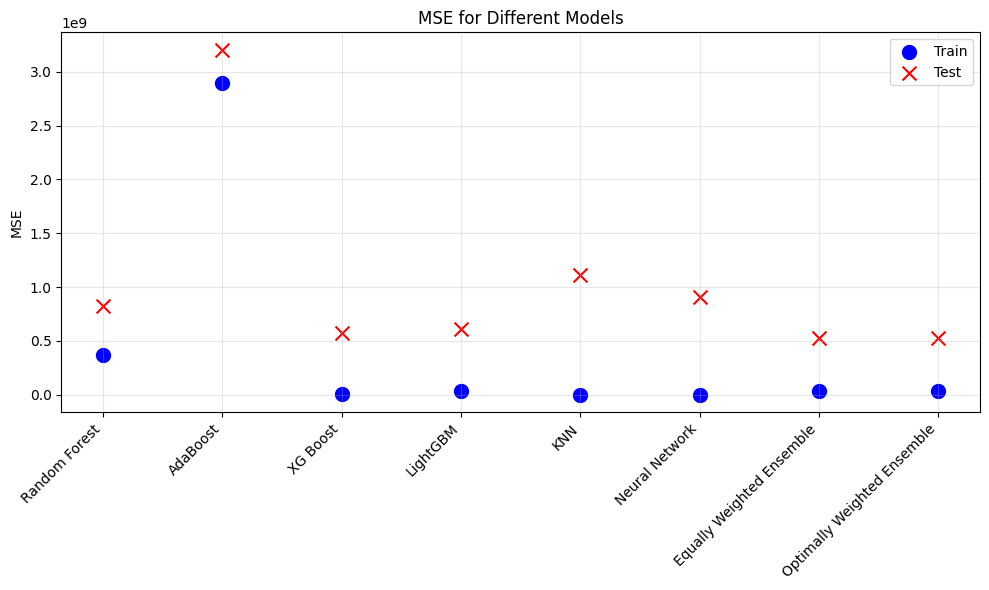

In [672]:
models = models + ["Equally Weighted Ensemble", "Optimally Weighted Ensemble"]
train_mse_list = train_mse_list + [avg_train_mse, train_mse]
test_mse_list  = test_mse_list + [avg_test_mse, test_mse]

plot_dot(train_mse_list, test_mse_list, 'MSE')

In [673]:
# Generate predictions on holdout
y_holdout_pred_weighted = (
    optimized_weights[0]*best_rf.predict(X_holdout) +
    optimized_weights[1]*best_xgb.predict(X_holdout) +
    optimized_weights[2]*best_nn.predict(X_holdout) +
    optimized_weights[3]*best_lgb.predict(X_holdout)
)

# Write predictions to csv
df_holdout['SalePrice'] = y_holdout_pred_weighted
df_holdout[['SalePrice']].to_csv('holdout_predictions_template.csv', index=False)